In [2]:
data = [50, 50, 47, 97, 49]

print(data * 2)

[50, 50, 47, 97, 49, 50, 50, 47, 97, 49]


In [3]:
import numpy as np

grades = np.array(data)

print(grades * 2)

[100 100  94 194  98]


In [4]:
grades.shape

(5,)

In [5]:
int(grades[0])

50

In [6]:
float(grades.mean())

58.6

In [7]:
study_hours = [10.0, 11.5, 9.0, 16.0, 9.25]
student_data = np.array([study_hours, grades])

In [8]:
float(student_data[0][0])

10.0

In [9]:
avg_study = student_data[0].mean()
avg_grade = student_data[1].mean()

print(f'Average Study Time: {avg_study}\nAverageGrage: {avg_grade}')

Average Study Time: 11.15
AverageGrage: 58.6


In [10]:
import pandas as pd 
df_students = pd.DataFrame({'Name':['Dan', 'John', 'Pedro', 'Rosie', 'Rhonda'],
                            'StudyHours': student_data[0],
                            'Grade': student_data[1]})
df_students

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,John,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Rhonda,9.25,49.0


In [11]:
df_students.loc[4]

Name          Rhonda
StudyHours      9.25
Grade           49.0
Name: 4, dtype: object

In [12]:
df_students.query('Name=="Dan"')

,Name,StudyHours,Grade
0,Dan,10.0,50.0


In [13]:
import pandas as pd

url = "https://gist.githubusercontent.com/SoumenAtta/96fc49b520f9b0a8283f758d3d3d013d/raw/student_study_hours_scores.csv"

df = pd.read_csv(url)

df.to_csv("students.csv")

print(df)

    Hours  Scores
0     2.5      21
1     5.0      47
2     3.2      33
3     8.5      96
4     2.5      30
5     1.5      20
6     5.0      44
7     3.5      37
8     7.0      88
9     3.0      33
10    5.0      50
11    3.5      36
12    8.0      94
13    2.0      22
14    5.5      49
15    2.5      26
16    4.0      42
17    7.5      90
18    2.5      29
19    3.5      36
20    6.0      68
21    4.5      46
22    8.0      92
23    3.5      35
24    7.0      85
25    2.5      25
26    4.0      40
27    7.5      89
28    3.5      36


In [14]:
students = df.head(5)

print(students)

   Hours  Scores
0    2.5      21
1    5.0      47
2    3.2      33
3    8.5      96
4    2.5      30


In [15]:
df_students.isnull().sum()

Name          0
StudyHours    0
Grade         0
dtype: int64

In [16]:
df_students.StudyHours = df_students.StudyHours.fillna(df_students.StudyHours.mean())

In [17]:
df_students.dropna(axis=0)

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,John,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Rhonda,9.25,49.0


In [18]:
mean_study = df_students["StudyHours"].mean()
mean_grade = df_students["Grade"].mean()

print("Mean Study Hours:", mean_study)
print("Mean Grade:", mean_grade)

Mean Study Hours: 11.15
Mean Grade: 58.6


In [19]:
df_students[df_students.StudyHours > mean_study]

,Name,StudyHours,Grade
1,John,11.5,50.0
3,Rosie,16.0,97.0


In [20]:
float(df_students[df_students.StudyHours > mean_study].Grade.mean())

73.5

In [21]:

passed = pd.Series(df_students.Grade >= 60)
df_students = pd.concat([df_students, passed.rename('Passed')], axis=1)


In [32]:
df_students

,Name,StudyHours,Grade,Passed
3,Rosie,16.00,97.0,True
1,John,11.50,50.0,False
0,Dan,10.00,50.0,False
4,Rhonda,9.25,49.0,False
2,Pedro,9.00,47.0,False


In [34]:
df_students.to_csv("students.csv", index=False)

In [23]:
df_students.groupby(df_students.Passed).count()

,Name,StudyHours,Grade
Passed,,,
False,4,4,4
True,1,1,1


In [25]:
print(df_students.groupby(df_students.Passed).Grade.mean())

Passed
False    49.0
True     97.0
Name: Grade, dtype: float64


In [27]:
df_students.groupby(df_students.Passed)[['StudyHours', 'Grade']].mean()

,StudyHours,Grade
Passed,,
False,9.9375,49.0
True,16.0000,97.0


In [31]:
df_students = df_students.sort_values('StudyHours', ascending=False)

In [ ]:
import pandas as pd

url = "students.csv"

df_students = pd.read_csv(url)

df_students.to_csv("grades.csv", index=False)

df_students = df_students.dropna(axis=0, how="any")

passes = pd.Series(df_students["Grade"] >= 60)

df_students = pd.concat(
    [df_students, passes.rename("Pass")],
    axis=1
)

df_students

,Name,StudyHours,Grade,Passed,Pass
0,Rosie,16.00,97.0,True,True
1,John,11.50,50.0,False,False
2,Dan,10.00,50.0,False,False
3,Rhonda,9.25,49.0,False,False
4,Pedro,9.00,47.0,False,False


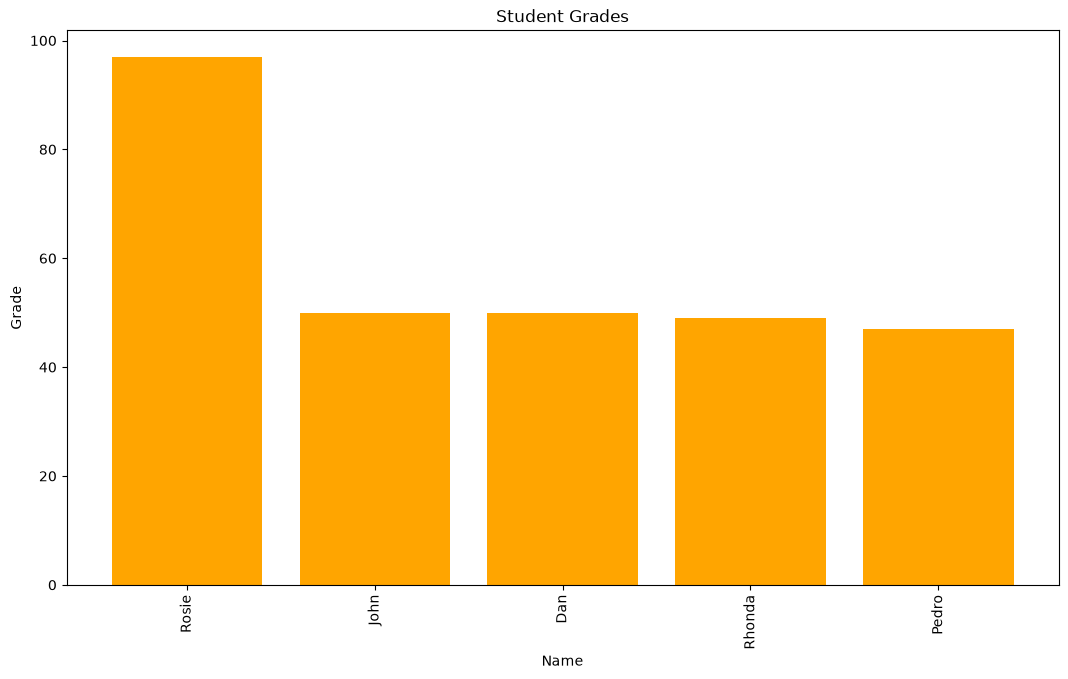

In [45]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(12.8, 7.2))

plt.bar(x = df_students.Name, height=df_students.Grade, color = "orange")

plt.title("Student Grades")
plt.xlabel("Name")
plt.ylabel("Grade")
plt.xticks(rotation=90)

plt.show()

C:\Users\Ashish\AppData\Local\Temp\ipykernel_24056\2529617545.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(df_students.Name, rotation=90)
C:\Users\Ashish\AppData\Local\Temp\ipykernel_24056\2529617545.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


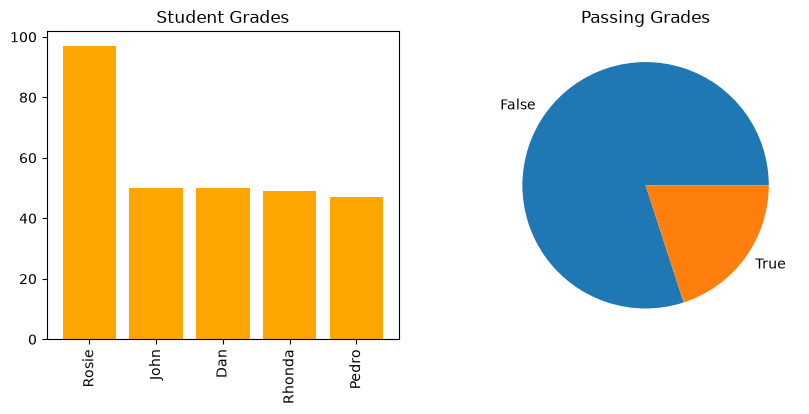

In [50]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(x = df_students.Name, height=df_students.Grade, color = "orange")

ax[0].set_title("Student Grades")
ax[0].set_xticklabels(df_students.Name, rotation=90)

passes_count = df_students.Pass.value_counts()
ax[1].pie(passes_count, labels=passes_count.index)
ax[1].set_title("Passing Grades")

fig.show()

<Axes: xlabel='Name'>

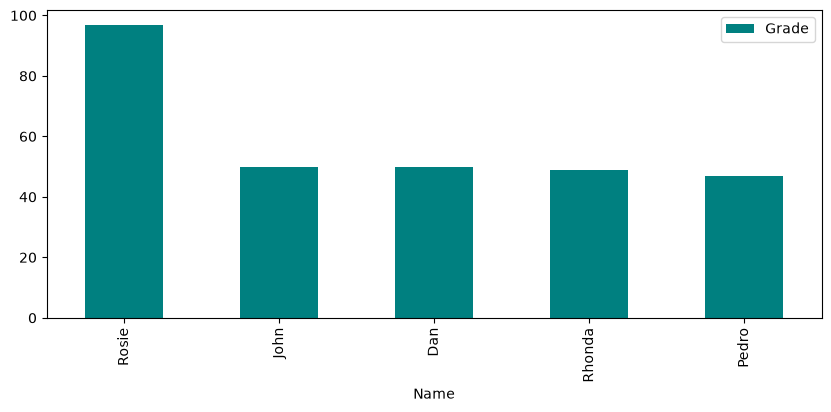

In [51]:
df_students.plot.bar(x='Name', y='Grade', figsize=(10, 4), color="teal")

Minimum: 47.0
Maximum: 97.0
Mean:58.6
Median:50.0
Mode:50.0


C:\Users\Ashish\AppData\Local\Temp\ipykernel_24056\1788299373.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


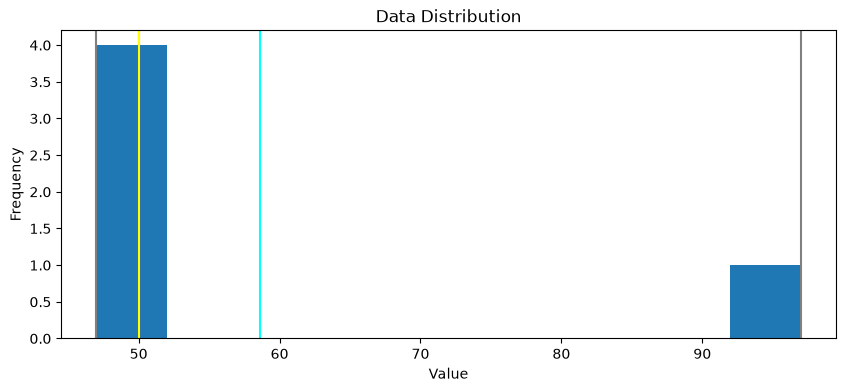

In [54]:
import matplotlib.pyplot as plt

grades = df_students.Grade

min_val = df_students.Grade.min()
max_val = df_students.Grade.max()
mean_val = df_students.Grade.mean()
med_val = df_students.Grade.median()
mode_val = df_students.Grade.mode()[0]

print(f"Minimum: {min_val}\nMaximum: {max_val}\nMean:{mean_val}\nMedian:{med_val}\nMode:{mode_val}")

fig = plt.figure(figsize=(10, 4))

plt.hist(grades)

plt.axvline(x = min_val, color='gray')
plt.axvline(x = max_val, color='gray')
plt.axvline(x = mean_val, color='cyan')
plt.axvline(x = med_val, color='red')
plt.axvline(x = mode_val, color='yellow')

plt.title("Data Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

fig.show()

C:\Users\Ashish\AppData\Local\Temp\ipykernel_24056\2479874505.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(var_data, vert=False)


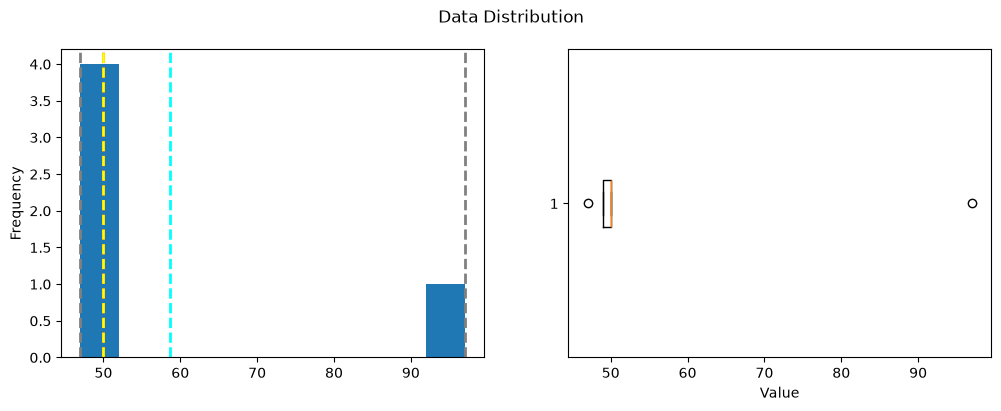

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def show_distribution(var_data):

    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mode_val = stats.mode(var_data, keepdims=True).mode[0]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].hist(var_data)

    ax[0].set_ylabel("Frequency")

    ax[0].axvline(x=min_val,color="gray",linestyle="dashed",linewidth=2)
    ax[0].axvline(x=mean_val,color="cyan",linestyle="dashed",linewidth=2)
    ax[0].axvline(x=med_val,color="red",linestyle="dashed",linewidth=2)
    ax[0].axvline(x=mode_val,color="yellow",linestyle="dashed",linewidth=2)
    ax[0].axvline(x=max_val,color="gray",linestyle="dashed",linewidth=2)

    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel("Value")

    fig.suptitle("Data Distribution")

    plt.show()

col = df_students["Grade"]

show_distribution(col)